In [1]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.3.3
numpy version: 2.3.5


In [2]:
# Sintering experiment data
data = {
    'temp_C':      [200, 250, 300, 350, 400, 450, 500, 550],
    'time_h':      [1,   2,   1,   3,   2,   1,   4,   2  ],
    'hardness_HV': [120, 145, 180, 210, 195, 170, 155, 140],
    'tensile_MPa': [350, 410, 490, 530, 510, 460, 420, 390],
    'sample_id':   ['S01','S02','S03','S04','S05','S06','S07','S08']
}

df = pd.DataFrame(data)
df

,temp_C,time_h,hardness_HV,tensile_MPa,sample_id
0,200,1,120,350,S01
1,250,2,145,410,S02
2,300,1,180,490,S03
3,350,3,210,530,S04
4,400,2,195,510,S05
5,450,1,170,460,S06
6,500,4,155,420,S07
7,550,2,140,390,S08


In [3]:
print("=== Shape (rows, columns) ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
print(df.describe())

=== Shape (rows, columns) ===
(8, 5)

=== Data Types ===
temp_C          int64
time_h          int64
hardness_HV     int64
tensile_MPa     int64
sample_id      object
dtype: object

=== Basic Statistics ===
           temp_C    time_h  hardness_HV  tensile_MPa
count    8.000000  8.000000     8.000000     8.000000
mean   375.000000  2.000000   164.375000   445.000000
std    122.474487  1.069045    30.052038    62.792174
min    200.000000  1.000000   120.000000   350.000000
25%    287.500000  1.000000   143.750000   405.000000
50%    375.000000  2.000000   162.500000   440.000000
75%    462.500000  2.250000   183.750000   495.000000
max    550.000000  4.000000   210.000000   530.000000


In [4]:
# Filter 1: hardness above 170 HV
high_hardness = df[df['hardness_HV'] > 170]
print("=== Samples with hardness > 170 HV ===")
print(high_hardness)

# Filter 2: temp 350°C or above
high_temp = df[df['temp_C'] >= 350]
print("\n=== Samples at 350°C or above ===")
print(high_temp[['sample_id', 'temp_C', 'hardness_HV', 'tensile_MPa']])

# Filter 3: best sample (highest tensile strength)
best = df[df['tensile_MPa'] == df['tensile_MPa'].max()]
print("\n=== Best sample (highest tensile strength) ===")
print(best)

=== Samples with hardness > 170 HV ===
   temp_C  time_h  hardness_HV  tensile_MPa sample_id
2     300       1          180          490       S03
3     350       3          210          530       S04
4     400       2          195          510       S05

=== Samples at 350°C or above ===
  sample_id  temp_C  hardness_HV  tensile_MPa
3       S04     350          210          530
4       S05     400          195          510
5       S06     450          170          460
6       S07     500          155          420
7       S08     550          140          390

=== Best sample (highest tensile strength) ===
   temp_C  time_h  hardness_HV  tensile_MPa sample_id
3     350       3          210          530       S04


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Windows font setting (to prevent broken characters)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("matplotlib version:", plt.matplotlib.__version__)
print("Ready!")

matplotlib version: 3.10.6
Ready!


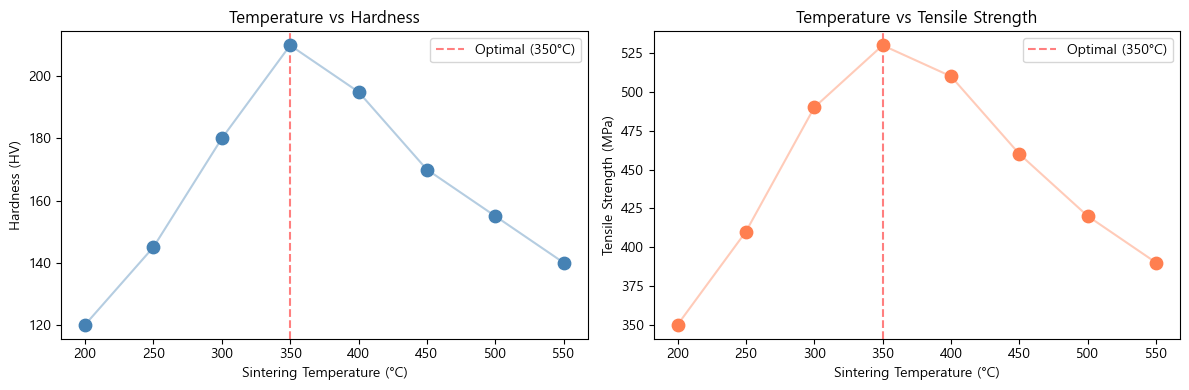

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: temp vs hardness (scatter plot)
axes[0].scatter(df['temp_C'], df['hardness_HV'],
                color='steelblue', s=80, zorder=5)
axes[0].plot(df['temp_C'], df['hardness_HV'],
             color='steelblue', alpha=0.4)
axes[0].set_xlabel('Sintering Temperature (°C)')
axes[0].set_ylabel('Hardness (HV)')
axes[0].set_title('Temperature vs Hardness')
axes[0].axvline(x=350, color='red', linestyle='--', alpha=0.5, label='Optimal (350°C)')
axes[0].legend()

# Graph 2: temp vs tensile strength
axes[1].scatter(df['temp_C'], df['tensile_MPa'],
                color='coral', s=80, zorder=5)
axes[1].plot(df['temp_C'], df['tensile_MPa'],
             color='coral', alpha=0.4)
axes[1].set_xlabel('Sintering Temperature (°C)')
axes[1].set_ylabel('Tensile Strength (MPa)')
axes[1].set_title('Temperature vs Tensile Strength')
axes[1].axvline(x=350, color='red', linestyle='--', alpha=0.5, label='Optimal (350°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

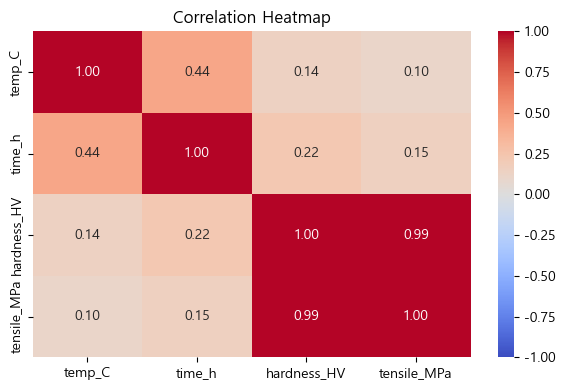

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

corr = df[['temp_C', 'time_h', 'hardness_HV', 'tensile_MPa']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()